# Step 1: Data preparation


In [21]:
import os
import copy
import random
import collections
import numpy as np
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt

# Scikit-learn Preprocessing, Splitting, and Metrics
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import classification_report, confusion_matrix, f1_score, balanced_accuracy_score, matthews_corrcoef, precision_recall_curve, auc, brier_score_loss
from sklearn.calibration import calibration_curve, CalibrationDisplay

# Imbalanced Learning Frameworks
from imblearn.over_sampling import SMOTE
from imblearn.combine import SMOTETomek

# Machine Learning & Deep Learning Frameworks
from xgboost import XGBClassifier
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

# Explainable AI (XAI) Libraries
import shap
import lime
import lime.lime_tabular

import preprocess

In [22]:
def set_seed(seed=42):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
    # Ensure fully deterministic behavior in PyTorch backends
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

In [23]:
filepath = "data/Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv"
df = preprocess.load_and_clean_dataset(filepath)

#change to a binary label
df['Label'] = df['Label'].astype(str).str.strip().str.upper()
df['Label'] = df['Label'].apply(lambda x: 0 if x == 'BENIGN' else 1)

X = df.drop(columns=['Label'])
y = df['Label'].values

print(f"[*] Cleaned Feature matrix shape: {X.shape}")
print(f"[*] Target distribution: Benign (0) = {np.sum(y == 0)}, Attack (1) = {np.sum(y == 1)}")


[*] Loading raw dataset from: data/Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv


c:\Users\Moritz\Documents\Uni\bachlor_thesis\ids-xai-thesis\preprocess.py:12: DtypeWarning: Columns (0: Flow ID, 1:  Source IP, 2:  Destination IP, 3:  Timestamp, 4:  Label) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path, encoding='latin-1')


[-] Dropped identifier columns: ['Flow ID', 'Source IP', 'Source Port', 'Destination IP', 'Destination Port', 'Timestamp']
[!] Purged 288737 malformed rows containing Infinity or empty cells.
[*] Cleaned Feature matrix shape: (170231, 78)
[*] Target distribution: Benign (0) = 168051, Attack (1) = 2180


In [24]:
# Step A: Split off 30% of the data into a temporary block, stratifying to preserve class ratios
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    stratify=y,
    random_state=42
)

# Step B: Split the temporary block evenly to yield a 15% Validation set and a 15% Test set
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=42
)

print("==================== DATA SPLIT SUMMARY ====================")
print(f"Training Set (70%):   X = {X_train.shape}, y = {y_train.shape}")
print(f"Validation Set (15%): X = {X_val.shape}, y = {y_val.shape}")
print(f"Test Set (15%):       X = {X_test.shape}, y = {y_test.shape}")

==================== DATA SPLIT SUMMARY ====================
Training Set (70%):   X = (119161, 78), y = (119161,)
Validation Set (15%): X = (25535, 78), y = (25535,)
Test Set (15%):       X = (25535, 78), y = (25535,)


In [25]:
# 1. Fit scaler ONLY on training data
scaler = MinMaxScaler()
scaler.fit(X_train)

X_train_scaled = pd.DataFrame(scaler.transform(X_train), columns=X_train.columns)
X_val_scaled = pd.DataFrame(scaler.transform(X_val), columns=X_val.columns)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns)

# 2. Correlated Feature Groups (Supervisor point 15 & 16)
corr_matrix = X_train_scaled.corr(method="spearman")
# Get upper triangle of correlation matrix
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
# Find columns with correlation > 0.90
to_drop = [column for column in upper.columns if any(upper[column].abs() > 0.90)]

print(f"[*] Features identified for potential removal (>0.90 correlation): {len(to_drop)}")

[*] Features identified for potential removal (>0.90 correlation): 39


In [26]:
# Initialize SMOTE-Tomek with a fixed seed for strict reproducibility
smote_tomek = SMOTETomek(random_state=42)

# Resample ONLY the training set
X_train_resampled, y_train_resampled = smote_tomek.fit_resample(
    X_train_scaled,
    y_train
)

print("================= RESAMPLING SUMMARY =================")
print(f"Original Training Class Ratios: 0 = {np.sum(y_train == 0)}, 1 = {np.sum(y_train == 1)}")
print(f"Resampled Training Data Shape:  X = {X_train_resampled.shape}, y = {y_train_resampled.shape}")
print(f"Resampled Training Class Ratios: 0 = {np.sum(y_train_resampled == 0)}, 1 = {np.sum(y_train_resampled == 1)}")

================= RESAMPLING SUMMARY =================
Original Training Class Ratios: 0 = 117635, 1 = 1526
Resampled Training Data Shape:  X = (235254, 78), y = (235254,)
Resampled Training Class Ratios: 0 = 117627, 1 = 117627


# Step 2: Model development

In [27]:
print("[*] Initializing XGBoost Classifier...")

# Initialize XGBoost with strict reproducibility parameters
xgb_model = XGBClassifier(
    n_estimators=500,
    max_depth=4,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=0.1,
    random_state=42,
    use_label_encoder=False,
    early_stopping_rounds=15
)

# Fit model with early stopping monitored against the validation split
xgb_model.fit(
    X_train_resampled, 
    y_train_resampled,
    eval_set=[(X_val_scaled, y_val)],
    verbose=False
)

print(f"[*] XGBoost training complete.")
print(f"    -> Best Iteration: {xgb_model.best_iteration}")

[*] Initializing XGBoost Classifier...


c:\Users\Moritz\Documents\Uni\bachlor_thesis\ids-xai-thesis\thesis_env\Lib\site-packages\xgboost\callback.py:385: UserWarning: [13:21:42] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:793: 
Parameters: { "use_label_encoder" } are not used.

  self.starting_round = model.num_boosted_rounds()


[*] XGBoost training complete.
    -> Best Iteration: 398


In [28]:
class RobustNetworkSecurityDNN(nn.Module):
    def __init__(self, input_dim):
        super(RobustNetworkSecurityDNN, self).__init__()
        
        # Layer 1: Input to Hidden 1
        self.fc1 = nn.Linear(input_dim, 128)
        self.relu1 = nn.ReLU()
        self.dropout1 = nn.Dropout(p=0.30)
        
        # Layer 2: Hidden 1 to Hidden 2
        self.fc2 = nn.Linear(128, 64)
        self.relu2 = nn.ReLU()
        self.dropout2 = nn.Dropout(p=0.30)
        
        # Layer 3: Hidden 2 to Output Layer
        self.fc3 = nn.Linear(64, 1)
        self.sigmoid = nn.Sigmoid()
        
    def forward(self, x):
        x = self.dropout1(self.relu1(self.fc1(x)))
        x = self.dropout2(self.relu2(self.fc2(x)))
        x = self.sigmoid(self.fc3(x))
        return x

# Set calculation device backend
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
input_features_count = X_train_resampled.shape[1]

# Instantiate model architecture
model_dnn = RobustNetworkSecurityDNN(input_dim=input_features_count).to(device)
print(f"[*] PyTorch Network mapped successfully onto target hardware device: {device.type.upper()}")

[*] PyTorch Network mapped successfully onto target hardware device: CPU


In [29]:
# Convert DataFrames/Arrays to PyTorch multi-dimensional tensors
train_dataset = TensorDataset(
    torch.FloatTensor(X_train_resampled.values),
    torch.FloatTensor(y_train_resampled).unsqueeze(1)
)
val_x_tensor = torch.FloatTensor(X_val_scaled.values).to(device)
val_y_tensor = torch.FloatTensor(y_val).unsqueeze(1).to(device)

# Configure data loader iterations
train_loader = DataLoader(train_dataset, batch_size=512, shuffle=True)

# Set optimizer equations and standard binary loss scoring
criterion = nn.BCELoss()
optimizer = optim.Adam(model_dnn.parameters(), lr=0.001)

# Early Stopping parameters
patience = 10
best_val_loss = float('inf')
best_model_weights = None
patience_counter = 0
max_epochs = 150

print("[*] Initiating DNN optimization loop...")
for epoch in range(1, max_epochs + 1):
    model_dnn.train()
    running_loss = 0.0
    
    for batch_x, batch_y in train_loader:
        batch_x, batch_y = batch_x.to(device), batch_y.to(device)
        
        optimizer.zero_grad()
        outputs = model_dnn(batch_x)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * batch_x.size(0)
        
    # Validation Evaluation Phase (Zero Leakage Check)
    model_dnn.eval()
    with torch.no_grad():
        val_outputs = model_dnn(val_x_tensor)
        val_loss = criterion(val_outputs, val_y_tensor).item()
        
    epoch_train_loss = running_loss / len(train_dataset)
    
    # Early stopping criteria tracking
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_weights = copy.deepcopy(model_dnn.state_dict())
        patience_counter = 0
    else:
        patience_counter += 1
        
    if patience_counter >= patience:
        print(f"[*] Early stopping triggered at Epoch {epoch}. Overfitting threshold neutralized.")
        break

# Roll back parameter matrix states to the optimal captured validation validation loss weights
if best_model_weights is not None:
    model_dnn.load_state_dict(best_model_weights)
print(f"[*] Restored optimal model configurations. Best Validation Loss: {best_val_loss:.5f}")

[*] Initiating DNN optimization loop...
[*] Early stopping triggered at Epoch 21. Overfitting threshold neutralized.
[*] Restored optimal model configurations. Best Validation Loss: 0.04361


In [30]:
# Helper function to generate clean inference probability matrices from our DNN
def get_dnn_probabilities(df_input):
    model_dnn.eval()
    with torch.no_grad():
        tensor_input = torch.FloatTensor(df_input.values).to(device)
        probs = model_dnn(tensor_input).cpu().numpy().flatten()
    return probs

# Step A: Collect raw feature inference array probabilities from validation subsets
xgb_val_probs = xgb_model.predict_proba(X_val_scaled)[:, 1]
dnn_val_probs = get_dnn_probabilities(X_val_scaled)

# Step B: Declare target tuning thresholds range
thresholds_pool = np.arange(0.50, 0.96, 0.05)

best_xgb_threshold = 0.50
best_xgb_f1 = 0.0
best_dnn_threshold = 0.50
best_dnn_f1 = 0.0

print("================= VAL THRESHOLD CALIBRATION =================")
for t in thresholds_pool:
    # Evaluate XGBoost arrays
    xgb_preds = (xgb_val_probs >= t).astype(int)
    xgb_f1 = f1_score(y_val, xgb_preds, zero_division=0)
    if xgb_f1 > best_xgb_f1:
        best_xgb_f1 = xgb_f1
        best_xgb_threshold = t
        
    # Evaluate DNN arrays
    dnn_preds = (dnn_val_probs >= t).astype(int)
    dnn_f1 = f1_score(y_val, dnn_preds, zero_division=0)
    if dnn_f1 > best_dnn_f1:
        best_dnn_f1 = dnn_f1
        best_dnn_threshold = t
        
    print(f"Threshold: {t:.2f} | XGB F1: {xgb_f1:.4f} | DNN F1: {dnn_f1:.4f}")

print("\n[*] Calibrated Decision Parameter Options Frozen:")
print(f"    -> Selected Frozen XGBoost Threshold: {best_xgb_threshold:.2f} (Val F1: {best_xgb_f1:.4f})")
print(f"    -> Selected Frozen DNN Threshold:     {best_dnn_threshold:.2f} (Val F1: {best_dnn_f1:.4f})")

================= VAL THRESHOLD CALIBRATION =================
Threshold: 0.50 | XGB F1: 0.9954 | DNN F1: 0.5195
Threshold: 0.55 | XGB F1: 0.9954 | DNN F1: 0.5304
Threshold: 0.60 | XGB F1: 0.9954 | DNN F1: 0.5450
Threshold: 0.65 | XGB F1: 0.9954 | DNN F1: 0.6054
Threshold: 0.70 | XGB F1: 0.9954 | DNN F1: 0.6681
Threshold: 0.75 | XGB F1: 0.9970 | DNN F1: 0.7687
Threshold: 0.80 | XGB F1: 0.9970 | DNN F1: 0.8626
Threshold: 0.85 | XGB F1: 0.9969 | DNN F1: 0.8555
Threshold: 0.90 | XGB F1: 0.9969 | DNN F1: 0.8547
Threshold: 0.95 | XGB F1: 0.9985 | DNN F1: 0.8571

[*] Calibrated Decision Parameter Options Frozen:
    -> Selected Frozen XGBoost Threshold: 0.95 (Val F1: 0.9985)
    -> Selected Frozen DNN Threshold:     0.80 (Val F1: 0.8626)


In [31]:
def calculate_advanced_metrics(y_true, probs, threshold, fn_cost=10, fp_cost=1):
    preds = (probs >= threshold).astype(int)
    
    # Core scikit-learn operations
    balanced_acc = balanced_accuracy_score(y_true, preds)
    mcc = matthews_corrcoef(y_true, preds)
    
    # Calculate Precision-Recall Area Under Curve (PR-AUC)
    precision, recall, _ = precision_recall_curve(y_true, probs)
    pr_auc = auc(recall, precision)
    
    # Extract confusion elements to calculate operational cost
    cm = confusion_matrix(y_true, preds)
    tn, fp, fn, tp = cm.ravel()
    
    total_operational_cost = (fn * fn_cost) + (fp * fp_cost)
    
    return {
        "Balanced Accuracy": balanced_acc,
        "MCC": mcc,
        "PR-AUC": pr_auc,
        "Operational Cost": total_operational_cost,
        "False Negatives": fn,
        "False Positives": fp
    }

# Evaluate both models on validation data using the selected threshold
print("=================== ADVANCED OPERATIONAL METRICS ===================")
xgb_adv = calculate_advanced_metrics(y_val, xgb_val_probs, best_xgb_threshold)
dnn_adv = calculate_advanced_metrics(y_val, dnn_val_probs, best_dnn_threshold)

for metric in ["Balanced Accuracy", "MCC", "PR-AUC", "Operational Cost", "False Negatives", "False Positives"]:
    print(f"{metric:<20} | XGBoost: {xgb_adv[metric]:.4f} | DNN: {dnn_adv[metric]:.4f}")
print("====================================================================")

=================== ADVANCED OPERATIONAL METRICS ===================
Balanced Accuracy    | XGBoost: 0.9985 | DNN: 0.9784
MCC                  | XGBoost: 0.9984 | DNN: 0.8653
PR-AUC               | XGBoost: 1.0000 | DNN: 0.9171
Operational Cost     | XGBoost: 10.0000 | DNN: 217.0000
False Negatives      | XGBoost: 1.0000 | DNN: 13.0000
False Positives      | XGBoost: 0.0000 | DNN: 87.0000


In [32]:
def expected_calibration_error(y_true, probs, n_bins=10):
    prob_true, prob_pred = calibration_curve(y_true, probs, n_bins=n_bins, strategy='uniform')
    ece = 0.0
    n_samples = len(y_true)
    
    # Bin sorting simulation loop
    bin_edges = np.linspace(0, 1, n_bins + 1)
    for i in range(n_bins):
        bin_idx = (probs > bin_edges[i]) & (probs <= bin_edges[i+1])
        bin_weight = np.sum(bin_idx) / n_samples
        if bin_weight > 0:
            bin_actual = np.mean(y_true[bin_idx])
            bin_predicted = np.mean(probs[bin_idx])
            ece += bin_weight * np.abs(bin_actual - bin_predicted)
    return ece

# Compute calibration diagnostics on the validation split
xgb_brier = brier_score_loss(y_val, xgb_val_probs)
dnn_brier = brier_score_loss(y_val, dnn_val_probs)

xgb_ece = expected_calibration_error(y_val, xgb_val_probs)
dnn_ece = expected_calibration_error(y_val, dnn_val_probs)

print("==================== PROBABILITY CALIBRATION ====================")
print(f"Brier Score Loss | XGBoost: {xgb_brier:.5f} | DNN: {dnn_brier:.5f}")
print(f"ECE (Uniform)    | XGBoost: {xgb_ece:.5f}  | DNN: {dnn_ece:.5f}")
print("=================================================================")

==================== PROBABILITY CALIBRATION ====================
Brier Score Loss | XGBoost: 0.00009 | DNN: 0.01340
ECE (Uniform)    | XGBoost: 0.00018  | DNN: 0.01971


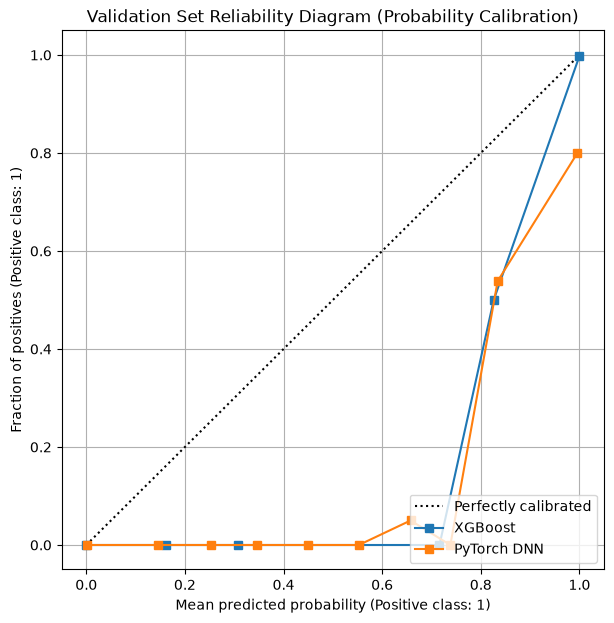

In [33]:
fig, ax = plt.subplots(figsize=(7, 7))

CalibrationDisplay.from_predictions(y_val, xgb_val_probs, n_bins=10, name="XGBoost", ax=ax)
CalibrationDisplay.from_predictions(y_val, dnn_val_probs, n_bins=10, name="PyTorch DNN", ax=ax)

ax.set_title("Validation Set Reliability Diagram (Probability Calibration)")
plt.grid(True)
plt.show()

In [34]:
# Step A: Extract test predictions using frozen configurations
xgb_test_probs = xgb_model.predict_proba(X_test_scaled)[:, 1]
dnn_test_probs = get_dnn_probabilities(X_test_scaled)

xgb_test_preds = (xgb_test_probs >= best_xgb_threshold).astype(int)
dnn_test_preds = (dnn_test_probs >= best_dnn_threshold).astype(int)

# Step B: Print formal validation summaries for your thesis report
print("=================== FINAL FROZEN XGBOOST REPORT ===================")
print(f"Applied Decision Threshold: {best_xgb_threshold:.2f}")
print(confusion_matrix(y_test, xgb_test_preds))
print(classification_report(y_test, xgb_test_preds, digits=4))

print("\n==================== FINAL FROZEN DNN REPORT ====================")
print(f"Applied Decision Threshold: {best_dnn_threshold:.2f}")
print(confusion_matrix(y_test, dnn_test_preds))
print(classification_report(y_test, dnn_test_preds, digits=4))

=================== FINAL FROZEN XGBOOST REPORT ===================
Applied Decision Threshold: 0.95
[[25207     1]
 [    4   323]]
              precision    recall  f1-score   support

           0     0.9998    1.0000    0.9999     25208
           1     0.9969    0.9878    0.9923       327

    accuracy                         0.9998     25535
   macro avg     0.9984    0.9939    0.9961     25535
weighted avg     0.9998    0.9998    0.9998     25535


==================== FINAL FROZEN DNN REPORT ====================
Applied Decision Threshold: 0.80
[[25126    82]
 [   19   308]]
              precision    recall  f1-score   support

           0     0.9992    0.9967    0.9980     25208
           1     0.7897    0.9419    0.8591       327

    accuracy                         0.9960     25535
   macro avg     0.8945    0.9693    0.9286     25535
weighted avg     0.9966    0.9960    0.9962     25535



In [35]:
# Standardized probability wrappers for the explainers
def xgb_predict_proba_wrapper(x_numpy):
    # Map numpy matrix rows directly back to pandas format to preserve column naming indices natively
    df_temp = pd.DataFrame(x_numpy, columns=X_train_scaled.columns)
    return xgb_model.predict_proba(df_temp)

def dnn_predict_proba_wrapper(x_numpy):
    df_temp = pd.DataFrame(x_numpy, columns=X_train_scaled.columns)
    probs_class_1 = get_dnn_probabilities(df_temp)
    probs_class_0 = 1.0 - probs_class_1
    return np.column_stack((probs_class_0, probs_class_1))

# Step 3: baseline explanation setup

In [36]:
# Map feature list and order cleanly from the step 1 variables
feature_list = X_train_scaled.columns.tolist()
x_train_unresampled_numpy = X_train_scaled.values

# Initialize LIME Tabular Explainer with fixed seed for absolute reproducibility
lime_explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=x_train_unresampled_numpy,
    feature_names=feature_list,
    class_names=["Benign", "Web Attack"],
    mode="classification",
    kernel_width=None, # Standard baseline width (to be evaluated later)
    random_state=42
)

In [37]:


# 1. Background dataset baseline for KernelExplainer
shap_background_baseline = shap.sample(X_train_scaled, 100, random_state=42)

# 2. KernelExplainers (Model-Agnostic Baseline in Probability Space)
shap_explainer_xgb_kernel = shap.KernelExplainer(
    model=xgb_predict_proba_wrapper,
    data=shap_background_baseline
)

shap_explainer_dnn = shap.KernelExplainer(
    model=dnn_predict_proba_wrapper,
    data=shap_background_baseline
)

# 3. TreeExplainer for XGBoost (Exact, Fast, Native Tree-Path)
shap_explainer_xgb_tree = shap.TreeExplainer(model=xgb_model)

In [38]:


def compute_attribution_metrics(attr_vec1, attr_vec2, k=10):
    """
    Computes stability/similarity metrics between two attribution vectors.
    """
    top_k_idx1 = set(np.argsort(np.abs(attr_vec1))[-k:])
    top_k_idx2 = set(np.argsort(np.abs(attr_vec2))[-k:])
    
    intersection = len(top_k_idx1.intersection(top_k_idx2))
    union = len(top_k_idx1.union(top_k_idx2))
    
    top_k_overlap = intersection / k
    jaccard_sim = intersection / union if union > 0 else 1.0
    
    spearman_corr, _ = stats.spearmanr(attr_vec1, attr_vec2)
    if np.isnan(spearman_corr):
        spearman_corr = 0.0
        
    norm1 = np.linalg.norm(attr_vec1)
    norm2 = np.linalg.norm(attr_vec2)
    u1 = attr_vec1 / norm1 if norm1 > 0 else attr_vec1
    u2 = attr_vec2 / norm2 if norm2 > 0 else attr_vec2
    attribution_dist = np.linalg.norm(u1 - u2)
    
    return {
        'top_k_overlap': top_k_overlap,
        'jaccard_similarity': jaccard_sim,
        'spearman_rank_corr': spearman_corr,
        'attribution_distance': attribution_dist
    }


def extract_aligned_lime_attributions(instance, predict_fn, num_features):
    """
    Generates LIME attributions aligned to Class 1.
    """
    # Ensure 1D numpy array for LIME
    if isinstance(instance, pd.DataFrame):
        data_row = instance.iloc[0].values
    elif isinstance(instance, pd.Series):
        data_row = instance.values
    else:
        data_row = instance

    exp = lime_explainer.explain_instance(
        data_row=data_row,
        predict_fn=predict_fn,
        labels=(1,),
        num_features=num_features
    )
    
    raw_local_exp = exp.local_exp[1]
    index_to_weight = {feature_idx: weight for feature_idx, weight in raw_local_exp}
    
    total_features = x_train_unresampled_numpy.shape[1]
    lime_vector = np.zeros(total_features)
    for idx in range(total_features):
        lime_vector[idx] = index_to_weight.get(idx, 0.0)
        
    fidelity_score = exp.score
    return lime_vector, fidelity_score


def extract_aligned_shap_attributions(instance, explainer, nsamples=None):
    """
    Extracts Class 1 SHAP values supporting both KernelExplainer and TreeExplainer.
    Automatically handles 1D/2D shape conversions.
    """
    # Force 2D DataFrame format to preserve feature names & avoid 1D shape crashes
    if isinstance(instance, np.ndarray):
        if instance.ndim == 1:
            instance_input = pd.DataFrame([instance], columns=X_train_scaled.columns)
        else:
            instance_input = pd.DataFrame(instance, columns=X_train_scaled.columns)
    elif isinstance(instance, pd.Series):
        instance_input = pd.DataFrame([instance.values], columns=X_train_scaled.columns)
    else:
        instance_input = instance

    # Execution path for TreeExplainer
    if isinstance(explainer, shap.TreeExplainer):
        raw_values = explainer.shap_values(instance_input)
        if isinstance(raw_values, list):
            shap_vector = raw_values[1]
        elif isinstance(raw_values, np.ndarray):
            if raw_values.ndim == 3: # Shape: (1, num_features, 2)
                shap_vector = raw_values[:, :, 1]
            elif raw_values.ndim == 2: # Shape: (1, num_features)
                shap_vector = raw_values[0]
            else:
                shap_vector = raw_values
        else:
            shap_vector = raw_values
        return np.array(shap_vector).flatten()

    # Execution path for KernelExplainer
    nsamples_param = nsamples if nsamples is not None else 100
    raw_values = explainer.shap_values(instance_input, nsamples=nsamples_param)
    
    if isinstance(raw_values, list):
        shap_vector = raw_values[1]
    elif isinstance(raw_values, np.ndarray):
        if raw_values.ndim == 3:
            shap_vector = raw_values[:, :, 1]
        elif raw_values.ndim == 2 and raw_values.shape[0] == 1:
            shap_vector = raw_values[0]
        elif raw_values.ndim == 2 and raw_values.shape[1] == 2:
            shap_vector = raw_values[:, 1]
        else:
            shap_vector = raw_values
    else:
        shap_vector = raw_values
        
    return np.array(shap_vector).flatten()

In [39]:
# Cell 16: Verification & Shape Alignment Check Across Explainers

sample_idx = 0
verification_sample = X_val_scaled.iloc[sample_idx].values

print("=================== SHAPE & ALIGNMENT CHECK ===================")

# 1. XGBoost Pipelines
lime_xgb_w, xgb_fid = extract_aligned_lime_attributions(
    instance=verification_sample,
    predict_fn=xgb_predict_proba_wrapper,
    num_features=X_val_scaled.shape[1]
)
shap_xgb_kernel_w = extract_aligned_shap_attributions(
    instance=verification_sample,
    explainer=shap_explainer_xgb_kernel,
    nsamples=100
)
shap_xgb_tree_w = extract_aligned_shap_attributions(
    instance=verification_sample,
    explainer=shap_explainer_xgb_tree
)

# 2. DNN Pipelines
lime_dnn_w, dnn_fid = extract_aligned_lime_attributions(
    instance=verification_sample,
    predict_fn=dnn_predict_proba_wrapper,
    num_features=X_val_scaled.shape[1]
)
shap_dnn_w = extract_aligned_shap_attributions(
    instance=verification_sample,
    explainer=shap_explainer_dnn,
    nsamples=100
)

# Display diagnostic dimensions
print(f"XGBoost Pipeline -> LIME Vector Shape:        {lime_xgb_w.shape} | Fidelity R2: {xgb_fid:.4f}")
print(f"XGBoost Pipeline -> KernelSHAP Vector Shape: {shap_xgb_kernel_w.shape}")
print(f"XGBoost Pipeline -> TreeSHAP Vector Shape:   {shap_xgb_tree_w.shape}")
print(f"DNN Pipeline     -> LIME Vector Shape:        {lime_dnn_w.shape} | Fidelity R2: {dnn_fid:.4f}")
print(f"DNN Pipeline     -> KernelSHAP Vector Shape: {shap_dnn_w.shape}")

# Assert exact feature count matching
assert lime_xgb_w.shape == shap_xgb_tree_w.shape == shap_dnn_w.shape == (78,), "Dimension mismatch!"
print("\n[+] Success: All explainers executed smoothly and return matching 78-feature vectors.")
print("===============================================================")

=================== SHAPE & ALIGNMENT CHECK ===================


  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

XGBoost Pipeline -> LIME Vector Shape:        (78,) | Fidelity R2: 0.0138
XGBoost Pipeline -> KernelSHAP Vector Shape: (78,)
XGBoost Pipeline -> TreeSHAP Vector Shape:   (78,)
DNN Pipeline     -> LIME Vector Shape:        (78,) | Fidelity R2: 0.0158
DNN Pipeline     -> KernelSHAP Vector Shape: (78,)

[+] Success: All explainers executed smoothly and return matching 78-feature vectors.


In [40]:


eval_samples = X_val_scaled.iloc[:15].values # Multi-observation evaluation sample
sampling_budgets = [100, 300, 500, 1000]
high_precision_budget = 2000

print("================= KERNELSHAP SAMPLING BUDGET SENSITIVITY =================")
budget_results = []

for idx, obs in enumerate(eval_samples):
    # Compute high-precision baseline attribution
    baseline_attr = extract_aligned_shap_attributions(
        obs, shap_explainer_dnn, nsamples=high_precision_budget
    )
    
    for budget in sampling_budgets:
        attr_budget = extract_aligned_shap_attributions(
            obs, shap_explainer_dnn, nsamples=budget
        )
        
        metrics = compute_attribution_metrics(baseline_attr, attr_budget, k=10)
        metrics['nsamples'] = budget
        metrics['obs_idx'] = idx
        budget_results.append(metrics)

# Aggregate and display summary
df_budget = pd.DataFrame(budget_results)
budget_summary = df_budget.groupby('nsamples').agg({
    'top_k_overlap': 'mean',
    'jaccard_similarity': 'mean',
    'spearman_rank_corr': 'mean',
    'attribution_distance': 'mean'
}).reset_index()

print("\n--- Stability Compared to Baseline (nsamples=2000) ---")
print(budget_summary.to_string(index=False))
print("==========================================================================")

================= KERNELSHAP SAMPLING BUDGET SENSITIVITY =================


  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

...

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]


--- Stability Compared to Baseline (nsamples=2000) ---
 nsamples  top_k_overlap  jaccard_similarity  spearman_rank_corr  attribution_distance
      100       0.353333            0.220938            0.285175              0.964139
      300       0.546667            0.381319            0.520132              0.712507
      500       0.640000            0.497466            0.619891              0.621375
     1000       0.726667            0.581041            0.714767              0.509667


In [41]:
# Cell 17: Multi-Observation Background-Size Sensitivity Audit

background_sizes = [25, 50, 100, 200]
eval_subset = X_val_scaled.iloc[:15] # Evaluates multiple observations (e.g., 15 instances)
target_k = 10

# Pre-compute attributions using largest background size as baseline reference
baseline_bg = shap.sample(X_train_scaled, 200, random_state=42)
explainer_baseline = shap.KernelExplainer(dnn_predict_proba_wrapper, baseline_bg)

baseline_attributions = [
    extract_aligned_shap_attributions(eval_subset.iloc[i].values, explainer_baseline, nsamples=500)
    for i in range(len(eval_subset))
]

bg_audit_records = []

print("================ MULTI-OBSERVATION BACKGROUND SIZE AUDIT ================")

for size in background_sizes[:-1]: # Compare smaller sizes against the baseline (200)
    temp_background = shap.sample(X_train_scaled, size, random_state=42)
    temp_explainer = shap.KernelExplainer(dnn_predict_proba_wrapper, temp_background)
    
    size_metrics = []
    for i in range(len(eval_subset)):
        obs = eval_subset.iloc[i].values
        attr_temp = extract_aligned_shap_attributions(obs, temp_explainer, nsamples=500)
        
        # Calculate comparison metrics against baseline background size
        m = compute_attribution_metrics(baseline_attributions[i], attr_temp, k=target_k)
        size_metrics.append(m)
        
    df_size = pd.DataFrame(size_metrics)
    bg_audit_records.append({
        'Background Size': size,
        'Top-k Overlap (k=10)': df_size['top_k_overlap'].mean(),
        'Jaccard Similarity': df_size['jaccard_similarity'].mean(),
        'Rank Correlation (Spearman)': df_size['spearman_rank_corr'].mean(),
        'Attribution Distance (Norm L2)': df_size['attribution_distance'].mean()
    })

df_bg_summary = pd.DataFrame(bg_audit_records)
print(df_bg_summary.to_string(index=False))
print("=========================================================================")

Using 200 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.


  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

...

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

 Background Size  Top-k Overlap (k=10)  Jaccard Similarity  Rank Correlation (Spearman)  Attribution Distance (Norm L2)
              25              0.526667            0.376114                     0.495288                        0.733035
              50              0.540000            0.380385                     0.506421                        0.713693
             100              0.520000            0.373432                     0.486595                        0.747723


# Step 4 Agreement Analysis

In [42]:
# =====================================================================
# STEP 4.1: SEPARATE DETERMINISTIC COHORT SAMPLING FOR EACH MODEL
# =====================================================================

rng = np.random.default_rng(42)
target_sample_size = 50

def extract_model_cohorts(y_true, preds, probs, threshold):
    """
    Extracts True Positive, True Negative, False Positive, False Negative, 
    and Borderline sample indices specific to a given model's predictions and threshold.
    """
    tp_all_idx = np.where((y_true == 1) & (preds == 1))[0]
    tn_all_idx = np.where((y_true == 0) & (preds == 0))[0]
    fp_all_idx = np.where((y_true == 0) & (preds == 1))[0]
    fn_all_idx = np.where((y_true == 1) & (preds == 0))[0]

    # Sample strictly up to target size per standard quadrant
    sampled_tp = rng.choice(tp_all_idx, min(target_sample_size, len(tp_all_idx)), replace=False) if len(tp_all_idx) > 0 else np.array([])
    sampled_tn = rng.choice(tn_all_idx, min(target_sample_size, len(tn_all_idx)), replace=False) if len(tn_all_idx) > 0 else np.array([])
    sampled_fp = rng.choice(fp_all_idx, min(target_sample_size, len(fp_all_idx)), replace=False) if len(fp_all_idx) > 0 else np.array([])
    sampled_fn = rng.choice(fn_all_idx, min(target_sample_size, len(fn_all_idx)), replace=False) if len(fn_all_idx) > 0 else np.array([])

    # Master set of standard sampled indices to avoid reuse in borderline category
    standard_sampled_indices = set(np.concatenate([sampled_tp, sampled_tn, sampled_fp, sampled_fn]))

    # Calculate distance to THIS model's frozen threshold
    distances_to_threshold = np.abs(probs - threshold)
    sorted_by_closeness = np.argsort(distances_to_threshold)

    # Filter out rows already selected in standard categories
    borderline_idx = [idx for idx in sorted_by_closeness if idx not in standard_sampled_indices]
    sampled_borderline = np.array(borderline_idx[:target_sample_size])

    return {
        'True Positive': sampled_tp,
        'True Negative': sampled_tn,
        'False Positive': sampled_fp,
        'False Negative': sampled_fn,
        'Borderline Case': sampled_borderline
    }

# Build separate cohort index maps for both models independently
model_cohort_samples = {
    'XGBoost': extract_model_cohorts(y_test, xgb_test_preds, xgb_test_probs, best_xgb_threshold),
    'DNN': extract_model_cohorts(y_test, dnn_test_preds, dnn_test_probs, best_dnn_threshold)
}

print("=====================================================================")
print("         MODEL-SPECIFIC STRATIFIED STUDY COHORTS DISCOVERED          ")
print("=====================================================================")
for model_name, cohorts in model_cohort_samples.items():
    print(f"\n--- {model_name} Cohorts ---")
    for cohort, indices in cohorts.items():
        print(f" -> {cohort:18s} | Selected Samples: {len(indices)}")
print("=====================================================================")

         MODEL-SPECIFIC STRATIFIED STUDY COHORTS DISCOVERED          

--- XGBoost Cohorts ---
 -> True Positive      | Selected Samples: 50
 -> True Negative      | Selected Samples: 50
 -> False Positive     | Selected Samples: 1
 -> False Negative     | Selected Samples: 4
 -> Borderline Case    | Selected Samples: 50

--- DNN Cohorts ---
 -> True Positive      | Selected Samples: 50
 -> True Negative      | Selected Samples: 50
 -> False Positive     | Selected Samples: 50
 -> False Negative     | Selected Samples: 19
 -> Borderline Case    | Selected Samples: 50


In [44]:
# =====================================================================
# STEP 4.2: SUITE OF EXPERIMENTAL METRICS & RANDOM BASELINE SIMULATION
# =====================================================================

agreement_records = []
num_features_total = X_test_scaled.shape[1]

# Pre-compute the 10,000-iteration random baseline values
print("[*] Running 10,000-iteration Monte Carlo random reference simulation...")
mc_overlaps = {5: [], 10: [], 20: []}
all_feature_pool = np.arange(num_features_total)
for _ in range(10000):
    for k_val in [5, 10, 20]:
        rand_set_a = set(rng.choice(all_feature_pool, k_val, replace=False))
        rand_set_b = set(rng.choice(all_feature_pool, k_val, replace=False))
        mc_overlaps[k_val].append(len(rand_set_a.intersection(rand_set_b)))

expected_random_overlap = {k: np.mean(mc_overlaps[k]) for k in [5, 10, 20]}
expected_random_jaccard = {k: expected_random_overlap[k] / (2 * k - expected_random_overlap[k]) for k in [5, 10, 20]}

print(f"     -> Expected Random Overlap: Top-5={expected_random_overlap[5]:.2f}, Top-10={expected_random_overlap[10]:.2f}, Top-20={expected_random_overlap[20]:.2f}")
print("Evaluating Multi-Model Local Explanation Consensus across Frameworks...")

# Iterate over each model and its OWN specific cohort samples
for model_label, cohorts in model_cohort_samples.items():
    
    # Assign explainer and prediction wrappers corresponding to the active model
    if model_label == 'XGBoost':
        predict_fn = xgb_predict_proba_wrapper
        explainer = shap_explainer_xgb_kernel
    else:
        predict_fn = dnn_predict_proba_wrapper
        explainer = shap_explainer_dnn

    for cohort_name, indices in cohorts.items():
        for test_idx in indices:
            instance_vector = X_test_scaled.iloc[test_idx].values
            
            # Extract clean attributions ONLY for the target model on its own cohort sample
            lime_v, lime_r2 = extract_aligned_lime_attributions(instance_vector, predict_fn, num_features_total)
            shap_v = extract_aligned_shap_attributions(instance_vector, explainer)
            
            row_metrics = {
                'Cohort': cohort_name,
                'Model': model_label,
                'Test_Index': test_idx,
                'LIME_R2': lime_r2
            }
            
            # Extract Top-K sets for each threshold size
            for k in [5, 10, 20]:
                top_lime = set(np.argsort(np.abs(lime_v))[-k:])
                top_shap = set(np.argsort(np.abs(shap_v))[-k:])
                
                overlap = len(top_lime.intersection(top_shap))
                union_len = len(top_lime.union(top_shap))
                jaccard = overlap / union_len if union_len > 0 else 0.0
                
                row_metrics[f'Overlap_{k}'] = overlap
                row_metrics[f'Jaccard_{k}'] = jaccard
                row_metrics[f'Random_Overlap_{k}'] = expected_random_overlap[k]
                row_metrics[f'Random_Jaccard_{k}'] = expected_random_jaccard[k]
                
            # Isolate the union of Top-10 features to calculate localized rank correlations
            top_10_lime = set(np.argsort(np.abs(lime_v))[-10:])
            top_10_shap = set(np.argsort(np.abs(shap_v))[-10:])
            top_10_union = list(top_10_lime.union(top_10_shap))
            
            lime_union_slice = lime_v[top_10_union]
            shap_union_slice = shap_v[top_10_union]
            
            # Handle zero-variance bounds safely
            if np.std(lime_union_slice) == 0 or np.std(shap_union_slice) == 0:
                row_metrics['Spearman_Signed'] = 0.0
                row_metrics['Spearman_Absolute'] = 0.0
                row_metrics['Kendall_Signed'] = 0.0
                row_metrics['Kendall_Absolute'] = 0.0
                row_metrics['Sign_Agreement'] = 0.0
            else:
                row_metrics['Spearman_Signed'], _ = stats.spearmanr(lime_union_slice, shap_union_slice)
                row_metrics['Kendall_Signed'], _ = stats.kendalltau(lime_union_slice, shap_union_slice)
                
                row_metrics['Spearman_Absolute'], _ = stats.spearmanr(np.abs(lime_union_slice), np.abs(shap_union_slice))
                row_metrics['Kendall_Absolute'], _ = stats.kendalltau(np.abs(lime_union_slice), np.abs(shap_union_slice))
                
                row_metrics['Sign_Agreement'] = np.mean(np.sign(lime_union_slice) == np.sign(shap_union_slice))
                
            agreement_records.append(row_metrics)

df_agreement = pd.DataFrame(agreement_records)
print("[+] Processing complete! Master analytical records built successfully.")

[*] Running 10,000-iteration Monte Carlo random reference simulation...
     -> Expected Random Overlap: Top-5=0.32, Top-10=1.29, Top-20=5.14
Evaluating Multi-Model Local Explanation Consensus across Frameworks...


  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

...

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

[+] Processing complete! Master analytical records built successfully.


In [45]:
# =====================================================================
# STEP 4.3: 5,000-SAMPLE BOOTSTRAP CONFIDENCE INTERVAL GENERATION
# =====================================================================

def compute_bootstrapped_ci(data_series, n_bootstrap=5000, alpha=0.05):
    """Generates mean and lower/upper 95% confidence intervals via resampling."""
    if len(data_series) == 0:
        return 0.0, 0.0, 0.0
    
    values = data_series.values
    boot_means = []
    
    # Resample with replacement 5,000 times
    for _ in range(n_bootstrap):
        boot_sample = rng.choice(values, size=len(values), replace=True)
        boot_means.append(np.mean(boot_sample))
        
    mean_val = np.mean(values)
    lower_bound = np.percentile(boot_means, (alpha / 2) * 100)
    upper_bound = np.percentile(boot_means, (1 - alpha / 2) * 100)
    return mean_val, lower_bound, upper_bound

# Complete reporting loop grouping observations by prediction cohort and network model architecture
report_rows = []
metrics_to_bootstrap = [
    'LIME_R2', 'Overlap_5', 'Overlap_10', 'Overlap_20', 
    'Jaccard_10', 'Spearman_Signed', 'Spearman_Absolute', 
    'Kendall_Signed', 'Kendall_Absolute', 'Sign_Agreement'
]

unique_groups = df_agreement.groupby(['Cohort', 'Model'])

for (cohort_name, model_type), group_df in unique_groups:
    row_summary = {'Cohort': cohort_name, 'Model': model_type}
    
    for metric in metrics_to_bootstrap:
        mean_v, low_v, high_v = compute_bootstrapped_ci(group_df[metric], n_bootstrap=5000)
        # Format string following rigorous master-thesis presentation conventions
        row_summary[metric] = f"{mean_v:.3f} [{low_v:.3f}, {high_v:.3f}]"
        
    # Append the baseline random reference indicators directly as static columns
    row_summary['Rand_Overlap_10'] = f"{group_df['Random_Overlap_10'].iloc[0]:.2f}"
    row_summary['Rand_Jaccard_10'] = f"{group_df['Random_Jaccard_10'].iloc[0]:.3f}"
    
    report_rows.append(row_summary)

df_master_report = pd.DataFrame(report_rows)

print("\n" + "="*145)
print("                                      FINAL ACADEMIC XAI AGREEMENT REPORT WITH 95% BOOTSTRAP CIs")
print("="*145)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
display(df_master_report)
print("="*145)


                                      FINAL ACADEMIC XAI AGREEMENT REPORT WITH 95% BOOTSTRAP CIs


,Cohort,Model,LIME_R2,Overlap_5,Overlap_10,Overlap_20,Jaccard_10,Spearman_Signed,Spearman_Absolute,Kendall_Signed,Kendall_Absolute,Sign_Agreement,Rand_Overlap_10,Rand_Jaccard_10
0,Borderline Case,DNN,"0.030 [0.028, 0.032]","0.620 [0.460, 0.800]","1.720 [1.380, 2.060]","4.660 [4.180, 5.160]","0.099 [0.078, 0.122]","-0.550 [-0.599, -0.497]","-0.603 [-0.647, -0.557]","-0.413 [-0.448, -0.374]","-0.455 [-0.487, -0.422]","0.537 [0.522, 0.552]",1.29,0.069
1,Borderline Case,XGBoost,"0.043 [0.041, 0.044]","1.300 [1.120, 1.480]","2.500 [2.200, 2.800]","4.900 [4.520, 5.280]","0.147 [0.127, 0.167]","-0.364 [-0.414, -0.310]","-0.435 [-0.478, -0.390]","-0.275 [-0.312, -0.236]","-0.328 [-0.359, -0.296]","0.564 [0.548, 0.578]",1.29,0.069
2,False Negative,DNN,"0.029 [0.025, 0.033]","0.579 [0.316, 0.842]","1.632 [1.105, 2.158]","5.211 [4.526, 5.895]","0.094 [0.061, 0.128]","-0.500 [-0.574, -0.417]","-0.616 [-0.684, -0.548]","-0.380 [-0.435, -0.321]","-0.464 [-0.515, -0.416]","0.504 [0.465, 0.535]",1.29,0.069
3,False Negative,XGBoost,"0.047 [0.034, 0.053]","0.750 [0.000, 1.500]","2.000 [1.250, 2.750]","5.500 [4.000, 7.000]","0.113 [0.067, 0.160]","-0.565 [-0.807, -0.324]","-0.483 [-0.678, -0.287]","-0.431 [-0.614, -0.248]","-0.352 [-0.499, -0.205]","0.443 [0.383, 0.487]",1.29,0.069
4,False Positive,DNN,"0.041 [0.039, 0.043]","0.640 [0.460, 0.820]","1.860 [1.580, 2.140]","4.620 [4.200, 5.020]","0.106 [0.088, 0.125]","-0.548 [-0.593, -0.503]","-0.589 [-0.630, -0.547]","-0.399 [-0.435, -0.365]","-0.430 [-0.463, -0.396]","0.544 [0.534, 0.556]",1.29,0.069
5,False Positive,XGBoost,"0.038 [0.038, 0.038]","2.000 [2.000, 2.000]","2.000 [2.000, 2.000]","5.000 [5.000, 5.000]","0.111 [0.111, 0.111]","-0.351 [-0.351, -0.351]","-0.351 [-0.351, -0.351]","-0.253 [-0.253, -0.253]","-0.253 [-0.253, -0.253]","0.556 [0.556, 0.556]",1.29,0.069
6,True Negative,DNN,"0.014 [0.013, 0.015]","0.180 [0.080, 0.300]","1.180 [0.960, 1.400]","5.260 [4.720, 5.800]","0.065 [0.052, 0.078]","0.428 [0.345, 0.507]","-0.718 [-0.745, -0.688]","0.339 [0.276, 0.400]","-0.530 [-0.557, -0.502]","0.328 [0.302, 0.352]",1.29,0.069
7,True Negative,XGBoost,"0.023 [0.019, 0.028]","1.220 [1.000, 1.440]","2.920 [2.580, 3.280]","7.260 [6.800, 7.720]","0.178 [0.153, 0.203]","0.325 [0.255, 0.396]","-0.420 [-0.481, -0.356]","0.254 [0.197, 0.311]","-0.319 [-0.363, -0.273]","0.359 [0.337, 0.381]",1.29,0.069
8,True Positive,DNN,"0.039 [0.038, 0.041]","0.640 [0.460, 0.820]","1.880 [1.560, 2.220]","4.780 [4.360, 5.200]","0.109 [0.089, 0.132]","-0.531 [-0.578, -0.480]","-0.574 [-0.620, -0.527]","-0.392 [-0.429, -0.353]","-0.425 [-0.461, -0.389]","0.544 [0.530, 0.558]",1.29,0.069
9,True Positive,XGBoost,"0.045 [0.044, 0.046]","0.920 [0.740, 1.080]","2.600 [2.340, 2.880]","4.800 [4.460, 5.140]","0.153 [0.135, 0.173]","-0.415 [-0.460, -0.367]","-0.476 [-0.513, -0.441]","-0.291 [-0.326, -0.256]","-0.336 [-0.366, -0.308]","0.562 [0.549, 0.575]",1.29,0.069
